In [1]:
import numpy as np
import nitools as nt
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
from py_util_dx.py_utils import setProjectPath
import os, pickle, torch
from nitools.cifti import surf_from_cifti
import SUITPy.flatmap as flatmap
from py_util_dx.data_utils import get_roi_pacels, get_glasser_labels, get_roi_vtx_from_fs32k

In [2]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB' # or Demand

resultsPath = os.path.join(mainResultsPath, 'START_A3_bayes_parcellation', dataset_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')

appendix = 'PFC_masked'   # or PFC masked
# appendix = 'somatosensory_masked'   
# appendix = 'visual_masked'   
# appendix = 'parietal_masked'   

PKL_output = os.path.join(resultsPath, f'output_{appendix}.pkl')

In [3]:
# Get the atlas
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

# loading saved U and U_indiv
with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf)

U = output['U']
U_roi = output['U_roi']
U_indiv = output['U_indiv']
ll = output['ll']

In [4]:
## dealing with PFC mask
if appendix == 'whole_cortex':
    included_vtx_inds_LR, included_vtx_inds_L, included_vtx_inds_R, excluded_vtx_inds_LR = get_roi_vtx_from_fs32k('whole_cortex')
else:
    included_vtx_inds_LR, included_vtx_inds_L, included_vtx_inds_R, excluded_vtx_inds_LR = get_roi_vtx_from_fs32k(appendix.rstrip('_masked'))

In [5]:
# Load colormap and labels
lid,cmap,names = nt.read_lut(os.path.join(surface_helpers_dir, 'atl-glasser.lut'))

if appendix != 'whole_cortex':
    parcels = get_roi_pacels(appendix.rstrip('_masked'))
    keep_inds = []
    for i in np.arange(len(names)):
        if names[i].split('_')[1] in parcels:
            keep_inds.append(i)
    lid = lid[keep_inds]
    cmap = cmap[keep_inds]
    names = list(map(names.__getitem__, keep_inds))

flat_surf_L = os.path.join(surface_helpers_dir, 'fs_LR.32k.L.flat.surf.gii')
flat_surf_R = os.path.join(surface_helpers_dir, 'fs_LR.32k.R.flat.surf.gii')
border_LR = os.path.join(surface_helpers_dir, 'fs_LR.32k.L.border')

In [6]:
def plot_probseg(surf_data, cmap, hemi):
    label = np.argmax(surf_data, axis=0) + 1
    label[excluded_vtx_inds_LR] = 181

    [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(label.reshape(1, -1)))

    if hemi == 'L':
        # left cortex
        keep_inds = np.arange(int(cmap.shape[0]/2))
        cmap = np.vstack([np.ones((1, 3)), cmap[keep_inds, :], np.ones((1, 3))])

        flatmap.plot(label_L.reshape(-1, ),
                     surf=flat_surf_L,
                     underlay=os.path.join(surface_helpers_dir, 'sub-01.L.sulc.32k_fs_LR.shape.gii'),
                     alpha=1,
                     label_names=list(map(names.__getitem__, keep_inds)),
                     new_figure=False,
                     frame=None,
                     render='matplotlib',
                     cmap=cmap,
                     borders=border_LR,
                     overlay_type='label',
                     bordersize=3,
                     undermap='gray',
                     underscale=[-1, 0.5]
        )

    else:
        # right cortex
        keep_inds = np.arange(int(cmap.shape[0]/2), cmap.shape[0])
        cmap = np.vstack([np.ones((1, 3)), cmap[keep_inds, :], np.ones((1, 3))])

        flatmap.plot(label_R.reshape(-1, ),
                     surf=flat_surf_R,
                     underlay=os.path.join(surface_helpers_dir, 'sub-01.R.sulc.32k_fs_LR.shape.gii'),
                     alpha=1,
                     label_names=list(map(names.__getitem__, keep_inds)),
                     new_figure=False,
                     frame=None,
                     render='matplotlib',
                     cmap=cmap,
                     borders=border_LR,
                     overlay_type='label',
                     bordersize=3,
                     undermap='gray',
                     underscale=[-1, 0.5]
        )

/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)


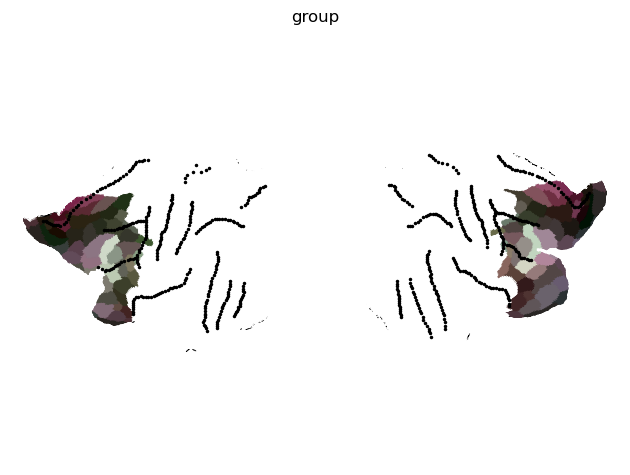

In [7]:
# Make a nifti image of the group
if torch.is_tensor(U_roi):
    surf_data = U_roi.detach().numpy()
else:
    surf_data = U_roi.copy()

# plot the group probabilistic atlas
plt.figure()
plt.subplot(1, 2, 1)
plot_probseg(surf_data, cmap, 'L')
plt.subplot(1, 2, 2)
plot_probseg(surf_data, cmap, 'R')
plt.suptitle('group')
plt.tight_layout()

/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in c

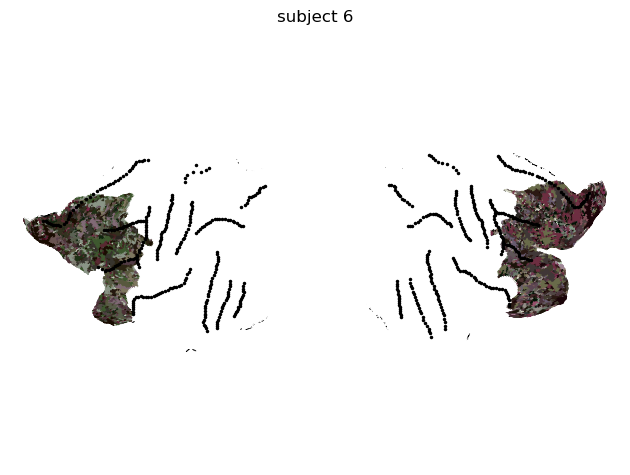

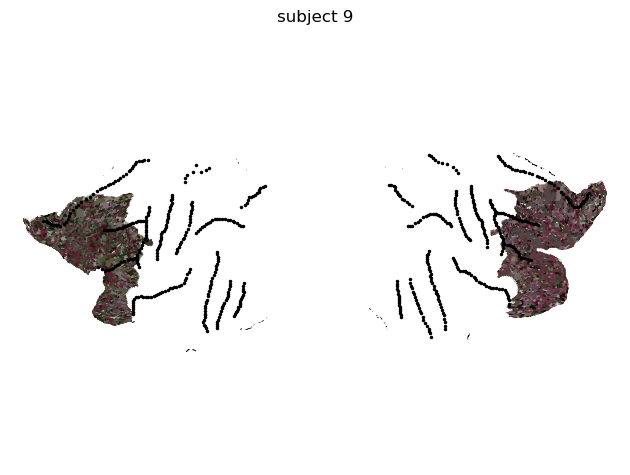

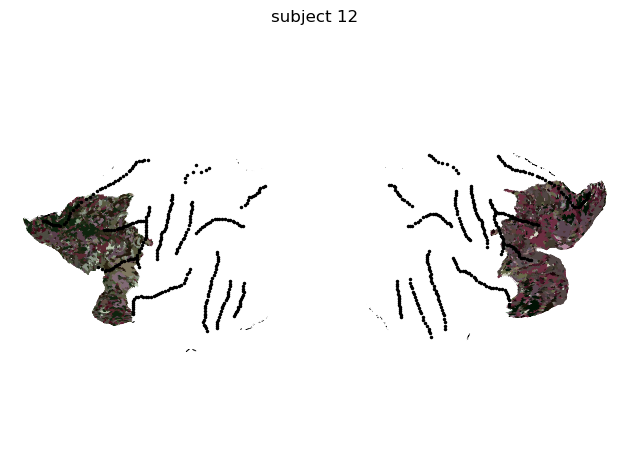

In [8]:
# plot 3 individual subjects
for i,s in enumerate([6, 9, 12]):
    if torch.is_tensor(U_indiv):
        surf_data = U_indiv[s].detach().numpy()
    else:
        surf_data = U_indiv[s]

    plt.figure()
    plt.subplot(1, 2, 1)
    plot_probseg(surf_data, cmap, 'L')
    plt.subplot(1, 2, 2)
    plot_probseg(surf_data, cmap, 'R')
    plt.suptitle(f'subject {s}')
    plt.tight_layout()

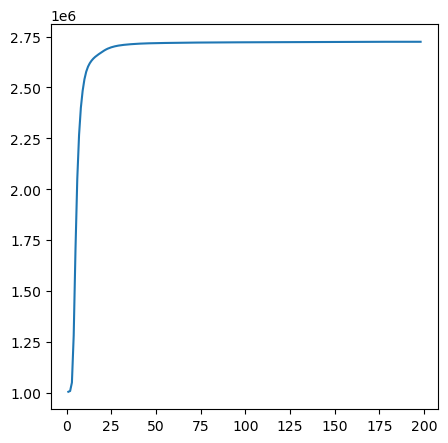

In [9]:
# inspect model training
plt.figure(figsize=(5,5))
plt.plot(ll)

## plotting Bassel's data 

In [10]:
with open(os.path.join(resultsPath, 'All Parcels_U.pickle'), 'rb') as pf:
    output = pickle.load(pf) 

In [12]:
output.shape 

(2, 180, 59518)

/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)


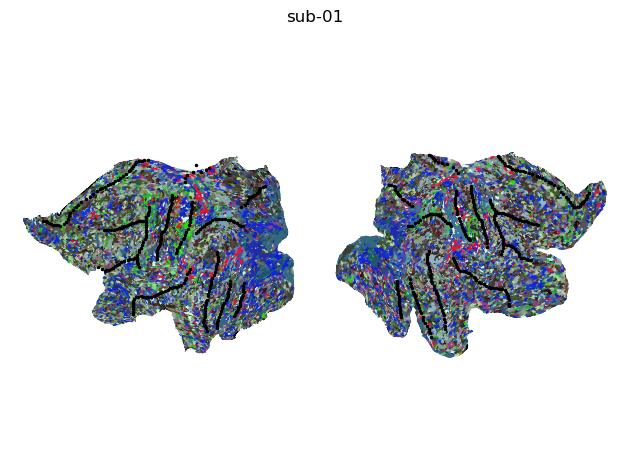

In [14]:
# Make a nifti image of the group
surf_data = output[0]

# plot the group probabilistic atlas
plt.figure()
plt.subplot(1, 2, 1)
plot_probseg(surf_data, cmap, 'L')
plt.subplot(1, 2, 2)
plot_probseg(surf_data, cmap, 'R')
plt.suptitle('sub-01')
plt.tight_layout()

/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/7T_exploration/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)


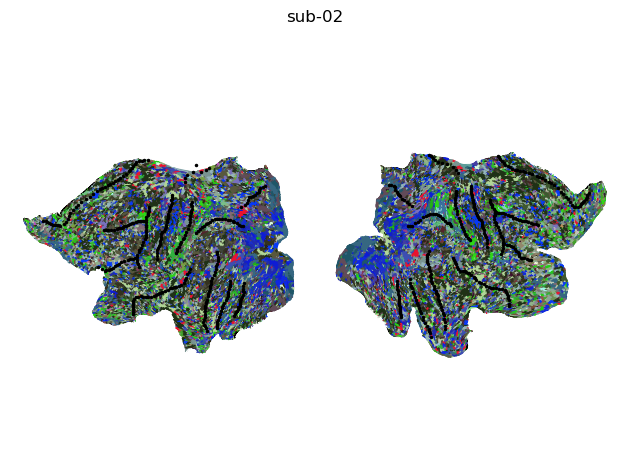

In [15]:
# Make a nifti image of the group
surf_data = output[1]

# plot the group probabilistic atlas
plt.figure()
plt.subplot(1, 2, 1)
plot_probseg(surf_data, cmap, 'L')
plt.subplot(1, 2, 2)
plot_probseg(surf_data, cmap, 'R')
plt.suptitle('sub-02')
plt.tight_layout()